<a href="https://colab.research.google.com/github/ipavlopoulos/diachronic-greek-letterforms/blob/main/cnn_embeddings_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data

In [28]:
from source import *
import torchvision.models as models


In [1]:
#@title Get the metadata
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from sklearn.decomposition import PCA
import numpy as np
from PIL import Image
import cv2
import pandas as pd

image_folder = 'data/hellchar/cliplets/'
image_files = [os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Adding metadata
filenames = os.listdir('data/hellchar/cliplets/')
data = pd.DataFrame({'filename': filenames})
data['letter'] = data.filename.apply(lambda x: x.split('_')[0])
data['TM'] = data.filename.apply(lambda x: int(x.split('_')[1]))
data['number'] = data.filename.apply(lambda x: x.split('_')[2].split('.')[0])
metadata = pd.read_csv('data/hellchar/hellchar.csv')
data['year'] = data.TM.apply(lambda x: metadata.loc[metadata['TM'] == x]['Year ante quem'].values[0])
data['region'] = data.TM.apply(lambda x: metadata.loc[metadata['TM'] == x]['Production Nome (supposed)'].values[0])

In [3]:
#@title Dataset development
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torchvision.transforms as transforms
import torch
import numpy as np
import cv2
import random


# Preprocess images for 2D CNN (resize and normalize, no flattening yet)
def preprocess_image_2d(image_path, size=(64, 64), otsu=False):
    img = Image.open(image_path).convert('L')  # Grayscale
    img_np = np.array(img)

    if otsu:
      _, img_np = cv2.threshold(img_np, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
      img_np = 255 - img_np

    # Resize to standard size
    img_resized = cv2.resize(img_np, size, interpolation=cv2.INTER_AREA)

    # Normalize pixel values to [0, 1]
    img_normalized = img_resized.astype(np.float32) / 255.0

    return img_normalized  # Return as 2D numpy array


# Preprocess all images for 2D CNN
image_data_2d = []

for img_file in image_files:
    try:
        processed_img_2d = preprocess_image_2d(img_file)
        image_data_2d.append(processed_img_2d)
    except Exception as e:
        print(f"Error processing image {img_file} for 2D CNN: {e}")

image_data_2d = np.array(image_data_2d)

# The original image data (image_data_2d) for the 2D CNN
train_data_split = data[data['letter'] != 'Unknown'].copy()
unk_data_split = data[data['letter'] == 'Unknown'].copy()

# Get the indices for splitting
train_indices_2d = train_data_split.index.tolist()
unk_indices_2d = unk_data_split.index.tolist()

# Encode the letter labels into integers
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(train_data_split['letter'])

# Split the indices for train/val/test
train_indices_2d, test_indices_2d, y_train_encoded_2d, y_test_encoded_2d = train_test_split(
    train_indices_2d,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_indices_2d, val_indices_2d, y_train_encoded_2d, y_val_encoded_2d = train_test_split(
    train_indices_2d,
    y_train_encoded_2d,
    test_size=0.1,
    random_state=42,
    stratify=y_train_encoded_2d
)


# Select image data and labels using the indices
X_train_2d = image_data_2d[train_indices_2d]
y_train_2d = y_train_encoded_2d

X_val_2d = image_data_2d[val_indices_2d]
y_val_2d = y_val_encoded_2d

X_test_2d = image_data_2d[test_indices_2d]
y_test_2d = y_test_encoded_2d

X_unk_2d = image_data_2d[unk_indices_2d]

# --- Data Augmentation for 2D Images ---
# Define image transformations including data augmentation
data_transform = transforms.Compose([
    transforms.RandomRotation(10),      # Rotate by up to 10 degrees
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Translate horizontally and vertically
    transforms.RandomResizedCrop(size=(64, 64), scale=(0.8, 1.0)), # Random crop and resize
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Adjust brightness and contrast
    RandomLacunae(num_lacunae=(0,2), size_range=(0.02,0.12), p=0.5, v=1),
    transforms.ToTensor(),             # Convert to PyTorch Tensor (adds channel dimension)
    #transforms.RandomErasing(p=0.5, value=0), # erase parts (lacunae)
    transforms.Normalize((0.5,), (0.5,)), # Normalize (assuming grayscale images)
])

# Transformation for validation and test sets (no augmentation)
test_transform = transforms.Compose([
    # Removed redundant transforms.ToPILImage()
    transforms.ToTensor(), # Adds channel dimension
    transforms.Normalize((0.5,), (0.5,))
])

# Create custom PyTorch dataset for 2D data with augmentation
class ImageDatasetAugmented(Dataset):
    def __init__(self, X, y=None, transform=None):
        self.X = X # Expecting numpy array of images
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        # Convert numpy array (H, W) to PIL Image (H, W) expected by transforms
        # Convert back to uint8 for PIL, as transforms expect uint8 or float in [0, 1]
        # Also ensure it's in the correct mode ('L' for grayscale)
        image = Image.fromarray((image * 255).astype(np.uint8))

        if self.transform:
            # Apply the transforms
            image = self.transform(image)

        # The transform pipeline includes ToTensor() and normalization, so 'image' is now a tensor
        if self.y is not None:
            return image, self.y[idx]
        else:
            return image


# Create DataLoaders for 2D data with augmentation
batch_size = 16
train_loader_2d_aug = DataLoader(ImageDatasetAugmented(X_train_2d, y_train_2d, transform=data_transform), batch_size=batch_size, shuffle=True)
val_loader_2d = DataLoader(ImageDatasetAugmented(X_val_2d, y_val_2d, transform=test_transform), batch_size=batch_size)
test_loader_2d = DataLoader(ImageDatasetAugmented(X_test_2d, y_test_2d, transform=test_transform), batch_size=batch_size)
unk_loader_2d = DataLoader(ImageDatasetAugmented(X_unk_2d, transform=test_transform), batch_size=batch_size) # Assuming unknown inference needs standard processing

In [4]:
#@title Train data - not augmented

class SimpleDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        # Convert numpy array (H, W) to PIL Image (H, W) expected by transforms
        # Convert back to uint8 for PIL, as transforms expect uint8 or float in [0, 1]
        # Also ensure it's in the correct mode ('L' for grayscale)
        image = Image.fromarray((image * 255).astype(np.uint8))

        # Apply only the test_transform (ToTensor and Normalize)
        if test_transform:
             image = test_transform(image)

        if self.y is not None:
            return image, self.y[idx]
        else:
            return image

train_dataset_no_aug = SimpleDataset(image_data_2d[train_indices_2d], y_train_encoded_2d)
test_dataset_no_aug = SimpleDataset(image_data_2d[test_indices_2d], y_test_encoded_2d)
train_loader_no_aug = DataLoader(train_dataset_no_aug, batch_size=batch_size)
test_loader_no_aug = DataLoader(test_dataset_no_aug, batch_size=batch_size)

In [7]:
#@title Load the model
model = CNN2D(num_classes=len(label_encoder.classes_), image_size=(64, 64))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.load_state_dict(torch.load('best_cnn_supcon_model.pth', map_location=torch.device(device)))
#evaluate(model, test_loader_2d, device, label_encoder)

<All keys matched successfully>

In [78]:
#@title Extract the embeddings
def extract_embeddings(model, dataloader, device, swin=False):
    model.eval()
    embeddings = []
    labels = []

    with torch.no_grad():
        for batch in dataloader:
            if isinstance(batch, (list, tuple)):
                images, targets = batch
                labels.extend(targets.numpy())
            else:
                images = batch
                targets = None

            images = images.to(device)

            if (swin == False):
                emb = model.get_embeddings(images)  # (batch_size, 512)
            else:
                x = model.features(images)
                x = model.norm(x)
                x = model.permute(x)
                x = model.avgpool(x)
                emb = model.flatten(x)  # These are your embeddings

                
            embeddings.append(emb.cpu().numpy())

    embeddings = np.vstack(embeddings)
    if labels:
        labels = np.array(labels)
        return embeddings, labels
    else:
        return embeddings

# Extract embeddings


In [80]:
train_embeddings, train_labels = extract_embeddings(model, train_loader_2d_aug, device)
train_embeddings_no_aug, train_labels_no_aug = extract_embeddings(model, train_loader_no_aug, device)
test_embeddings, test_labels = extract_embeddings(model, test_loader_2d, device)

## Resnet18 SupCon

In [68]:
import torchvision.models as models

In [70]:
class ResNetClassifier(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super(ResNetClassifier, self).__init__()
        self.resnet = models.resnet18(pretrained=pretrained)

        # Modify first conv layer for grayscale input
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        # Replace final layer
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)

    def get_embeddings(self, x):
        """Return embeddings before the final classification layer"""
        x = self.resnet.conv1(x)
        x = self.resnet.bn1(x)
        x = self.resnet.relu(x)
        x = self.resnet.maxpool(x)

        x = self.resnet.layer1(x)
        x = self.resnet.layer2(x)
        x = self.resnet.layer3(x)
        x = self.resnet.layer4(x)

        x = self.resnet.avgpool(x)
        x = torch.flatten(x, 1)

        # Get embeddings from the first part of fc layer
        x = self.resnet.fc[0](x)  # Dropout
        x = self.resnet.fc[1](x)  # Linear to 512
        x = self.resnet.fc[2](x)  # ReLU
        return x

In [ ]:
model_resnet_advanced = ResNetClassifier(num_classes=24, pretrained=True)
model_resnet_advanced.load_state_dict(torch.load('best_resnet_supcon_model.pth', map_location=torch.device('cpu')))

In [74]:
# Extract embeddings
train_embeddings_supcon, train_labels_supcon = extract_embeddings(model_resnet_advanced, train_loader_2d_aug, device)
train_embeddings_no_aug_supcon, train_labels_no_aug_supcon = extract_embeddings(model_resnet_advanced, train_loader_no_aug, device)
test_embeddings_supcon, test_labels_supcon = extract_embeddings(model_resnet_advanced, test_loader_2d, device)

# KMEANS

## ResNet18+SCL+LF

In [94]:
# resnetSupCon embeddings
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score, normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import numpy as np

num_classes = len(np.unique(train_labels_no_aug_supcon))

# 2. Run KMeans (unsupervised)
kmeans = KMeans(n_clusters=num_classes, random_state=42, n_init=20)
kmeans.fit(train_embeddings_no_aug_supcon)

# 3. Assign each cluster a majority-vote label
from scipy.stats import mode

cluster_labels = {}
for c in range(num_classes):
    indices = np.where(kmeans.labels_ == c)[0]
    if len(indices) > 0:
        majority_label = mode(train_labels[indices], keepdims=False).mode
        cluster_labels[c] = majority_label

# 4. Predict test set
test_clusters = kmeans.predict(test_embeddings_supcon)
y_pred_kmeans = np.array([cluster_labels[c] for c in test_clusters])

# 5. Evaluate
print("\nEvaluation on resnetSupCon features:")
#print(classification_report(test_labels, y_pred_kmeans, target_names=label_encoder.classes_, zero_division=0))
print(f"Normalized Mutual Information (NMI): {normalized_mutual_info_score(test_labels_supcon, y_pred_kmeans):.3f}")
print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(test_labels_supcon, y_pred_kmeans):.3f}")
print(f"Homogeneity: {homogeneity_score(test_labels_supcon, y_pred_kmeans):.3f}")
print(f"Completeness: {completeness_score(test_labels_supcon, y_pred_kmeans):.3f}")
print(f"V-measure: {v_measure_score(test_labels_supcon, y_pred_kmeans):.3f}")


Evaluation on resnetSupCon features:
Normalized Mutual Information (NMI): 0.659
Adjusted Rand Index (ARI): 0.389
Homogeneity: 0.579
Completeness: 0.764
V-measure: 0.659


## fCNN+SCL+LF

In [ ]:
#@title LefCNN embeddings
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score, normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import numpy as np

num_classes = len(np.unique(train_labels_no_aug))

# 2. Run KMeans (unsupervised)
kmeans = KMeans(n_clusters=num_classes, random_state=42, n_init=20)
kmeans.fit(train_embeddings_no_aug)

# 3. Assign each cluster a majority-vote label
from scipy.stats import mode

cluster_labels = {}
for c in range(num_classes):
    indices = np.where(kmeans.labels_ == c)[0]
    if len(indices) > 0:
        majority_label = mode(train_labels[indices], keepdims=False).mode
        cluster_labels[c] = majority_label

# 4. Predict test set
test_clusters = kmeans.predict(test_embeddings)
y_pred_kmeans = np.array([cluster_labels[c] for c in test_clusters])

# 5. Evaluate
print("\nEvaluation on LefCNN features:")
#print(classification_report(test_labels, y_pred_kmeans, target_names=label_encoder.classes_, zero_division=0))
print(f"Normalized Mutual Information (NMI): {normalized_mutual_info_score(test_labels, y_pred_kmeans):.3f}")
print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(test_labels, y_pred_kmeans):.3f}")
print(f"Homogeneity: {homogeneity_score(test_labels, y_pred_kmeans):.3f}")
print(f"Completeness: {completeness_score(test_labels, y_pred_kmeans):.3f}")
print(f"V-measure: {v_measure_score(test_labels, y_pred_kmeans):.3f}")


Evaluation on LefCNN features:
Normalized Mutual Information (NMI): 0.428
Adjusted Rand Index (ARI): 0.189
Homogeneity: 0.367
Completeness: 0.512
V-measure: 0.428


## PCA + Otsu

In [48]:
#@title Otsu+PCA 500D binarized
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score, normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import numpy as np
from scipy.stats import mode

# Preprocess all images with Otsu
image_data_ot = np.array([preprocess_image_2d(img_file, otsu=True) for img_file in image_files])

# 1. Get train and test Otsu-thresholded, flattened, raw (pixel) data
train_pixel_data = image_data_ot[train_indices_2d].reshape(image_data_ot[train_indices_2d].shape[0], -1)
test_pixel_data = image_data_ot[test_indices_2d].reshape(image_data_ot[test_indices_2d].shape[0], -1)
train_labels_pixel = y_train_encoded_2d
test_labels_pixel = y_test_encoded_2d
num_classes = len(np.unique(train_labels_pixel))

# 2. Apply PCA
n_components = 500
pca = PCA(n_components=n_components, random_state=42)

# Fit PCA on training data and transform both
train_pca_features = pca.fit_transform(train_pixel_data)
test_pca_features = pca.transform(test_pixel_data)

print(f"Explained variance ratio by {n_components} components: {pca.explained_variance_ratio_.sum():.4f}")

# 3. Run KMeans (unsupervised) on PCA features
kmeans_pca = KMeans(n_clusters=num_classes, random_state=42, n_init=20)
kmeans_pca.fit(train_pca_features)

cluster_labels = {}
for c in range(num_classes):
    indices = np.where(kmeans_pca.labels_ == c)[0]
    if len(indices) > 0:
        majority_label = mode(train_labels_pixel[indices], keepdims=False).mode
        cluster_labels[c] = majority_label

# 4. Predict test set
test_clusters_pca = kmeans_pca.predict(test_pca_features)
y_pred_kmeans_pca = np.array([cluster_labels[c] for c in test_clusters_pca])


# 5. Evaluate
print("\nEvaluation on PCA features:")
#print(f"KMeans-based classifier accuracy: {accuracy_score(test_labels_pixel, y_pred_kmeans_pca)}")
#print(classification_report(test_labels_pixel, y_pred_kmeans_pca, target_names=label_encoder.classes_, zero_division=0))
print(f"Normalized Mutual Information (NMI): {normalized_mutual_info_score(test_labels_pixel, y_pred_kmeans_pca)}")
print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(test_labels_pixel, y_pred_kmeans_pca)}")
print(f"Homogeneity: {homogeneity_score(test_labels_pixel, y_pred_kmeans_pca)}")
print(f"Completeness: {completeness_score(test_labels_pixel, y_pred_kmeans_pca)}")
print(f"V-measure: {v_measure_score(test_labels_pixel, y_pred_kmeans_pca)}")

Explained variance ratio by 500 components: 0.9061

Evaluation on PCA features:
Normalized Mutual Information (NMI): 0.3183444247534433
Adjusted Rand Index (ARI): 0.1526306237024604
Homogeneity: 0.3013449128630169
Completeness: 0.3373765589653442
V-measure: 0.31834442475344327


# Spectral Clustering

## ResNet18+SCL+LF

## ResNet18+SCL+LF

In [39]:
## ResnetSupCon


from sklearn.cluster import SpectralClustering
from sklearn.metrics import classification_report, accuracy_score, normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import numpy as np
from scipy.stats import mode

sc_cnn = SpectralClustering(n_clusters=num_classes,
                            assign_labels='discretize', # or 'kmeans'
                            random_state=42,
                            affinity='nearest_neighbors', # Use nearest neighbors graph
                            n_neighbors=min(10, test_embeddings_supcon.shape[0] - 1)) # Number of neighbors

test_clusters_sc_e = sc_cnn.fit_predict(test_embeddings_supcon)

cluster_labels_sc_e = {}
for c in range(num_classes): # Iterate up to n_clusters_spectral
    indices = np.where(test_clusters_sc_e == c)[0]
    if len(indices) > 0:
        majority_label = mode(test_labels[indices], keepdims=False).mode
        cluster_labels_sc_e[c] = majority_label

# Handle potential clusters that didn't get a majority label (e.g., empty clusters if discretize is used)
# Assign a default value (-1 or a placeholder) for clusters not in the map
y_pred_spectral = np.array([cluster_labels_sc_e.get(c, -1) for c in test_clusters_sc_e])

# Filter out samples that couldn't be mapped if necessary (e.g., if -1 is used)
# For evaluation metrics that require all samples, you might need a different strategy
# or ensure that all predicted clusters are mapped.
# Assuming all predicted clusters are intended to be mapped if possible:

# Convert back to original labels for classification report
# Filter out -1 predictions if any (though with discretize, all should be assigned a cluster 0 to n_clusters-1)
valid_indices = y_pred_spectral != -1
y_pred_spectral_original = label_encoder.inverse_transform(y_pred_spectral[valid_indices])
test_labels_original = label_encoder.inverse_transform(test_labels_pixel[valid_indices])

# 5. Evaluate
print("\nEvaluation on CNN embeddings (before augmentation) using Spectral Clustering:")
if len(valid_indices) > 0:
    #print(f"Spectral Clustering-based classifier accuracy (mapped on test set): {accuracy_score(test_labels_original, y_pred_spectral_original)}")
    #print(classification_report(test_labels_original, y_pred_spectral_original, target_names=label_encoder.classes_, zero_division=0))
    # NMI, ARI, etc. are ideally computed between true labels and cluster assignments directly
    print(f"Normalized Mutual Information (NMI): {normalized_mutual_info_score(test_labels, test_clusters_sc_e)}")
    print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(test_labels, test_clusters_sc_e)}")
    print(f"Homogeneity: {homogeneity_score(test_labels, test_clusters_sc_e)}")
    print(f"Completeness: {completeness_score(test_labels, test_clusters_sc_e)}")
    print(f"V-measure: {v_measure_score(test_labels, test_clusters_sc_e)}")
else:
    print("No valid predictions to evaluate.")


Evaluation on CNN embeddings (before augmentation) using Spectral Clustering:
Normalized Mutual Information (NMI): 0.8364333363359002
Adjusted Rand Index (ARI): 0.7431566273221315
Homogeneity: 0.8296570635100462
Completeness: 0.8433212118967561
V-measure: 0.8364333363359002


## fCNN+SCL+LF

In [ ]:
#@title LefCNN Embeddings

from sklearn.cluster import SpectralClustering
from sklearn.metrics import classification_report, accuracy_score, normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import numpy as np
from scipy.stats import mode

sc_cnn = SpectralClustering(n_clusters=num_classes,
                            assign_labels='discretize', # or 'kmeans'
                            random_state=42,
                            affinity='nearest_neighbors', # Use nearest neighbors graph
                            n_neighbors=min(10, test_embeddings.shape[0] - 1)) # Number of neighbors

test_clusters_sc_e = sc_cnn.fit_predict(test_embeddings)

cluster_labels_sc_e = {}
for c in range(num_classes): # Iterate up to n_clusters_spectral
    indices = np.where(test_clusters_sc_e == c)[0]
    if len(indices) > 0:
        majority_label = mode(test_labels[indices], keepdims=False).mode
        cluster_labels_sc_e[c] = majority_label

# Handle potential clusters that didn't get a majority label (e.g., empty clusters if discretize is used)
# Assign a default value (-1 or a placeholder) for clusters not in the map
y_pred_spectral = np.array([cluster_labels_sc_e.get(c, -1) for c in test_clusters_sc_e])

# Filter out samples that couldn't be mapped if necessary (e.g., if -1 is used)
# For evaluation metrics that require all samples, you might need a different strategy
# or ensure that all predicted clusters are mapped.
# Assuming all predicted clusters are intended to be mapped if possible:

# Convert back to original labels for classification report
# Filter out -1 predictions if any (though with discretize, all should be assigned a cluster 0 to n_clusters-1)
valid_indices = y_pred_spectral != -1
y_pred_spectral_original = label_encoder.inverse_transform(y_pred_spectral[valid_indices])
test_labels_original = label_encoder.inverse_transform(test_labels_pixel[valid_indices])

# 5. Evaluate
print("\nEvaluation on CNN embeddings (before augmentation) using Spectral Clustering:")
if len(valid_indices) > 0:
    #print(f"Spectral Clustering-based classifier accuracy (mapped on test set): {accuracy_score(test_labels_original, y_pred_spectral_original)}")
    #print(classification_report(test_labels_original, y_pred_spectral_original, target_names=label_encoder.classes_, zero_division=0))
    # NMI, ARI, etc. are ideally computed between true labels and cluster assignments directly
    print(f"Normalized Mutual Information (NMI): {normalized_mutual_info_score(test_labels, test_clusters_sc_e)}")
    print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(test_labels, test_clusters_sc_e)}")
    print(f"Homogeneity: {homogeneity_score(test_labels, test_clusters_sc_e)}")
    print(f"Completeness: {completeness_score(test_labels, test_clusters_sc_e)}")
    print(f"V-measure: {v_measure_score(test_labels, test_clusters_sc_e)}")
else:
    print("No valid predictions to evaluate.")


Evaluation on CNN embeddings (before augmentation) using Spectral Clustering:
Normalized Mutual Information (NMI): 0.6310821666448804
Adjusted Rand Index (ARI): 0.4421922216818613
Homogeneity: 0.6314897152351612
Completeness: 0.6306751437598461
V-measure: 0.6310821666448804


## PCA + Otsu

In [ ]:
#@title Otsu-PCA features

print("Applying Spectral Clustering on Otsu-PCA features...")

# We will cluster the test set independently for evaluation.
sc = SpectralClustering(n_clusters=num_classes,
                        assign_labels='discretize', # or 'kmeans'
                        random_state=42,
                        affinity='nearest_neighbors', # Use nearest neighbors graph
                        n_neighbors=10) # Number of neighbors

test_clusters_sc = sc.fit_predict(test_pca_features)

# Map test clusters to true labels using the *test set's* true labels
cluster_labels_sc = {}
for c in range(num_classes):
    indices = np.where(test_clusters_sc == c)[0]
    if len(indices) > 0:
        majority_label = mode(test_labels[indices], keepdims=False).mode
        cluster_labels_sc[c] = majority_label

# Assign majority-vote labels to the clustered test data
y_pred_sc = np.array([cluster_labels_sc.get(c, -1) for c in test_clusters_sc])

# Convert back to original labels for classification report
y_pred_sc = label_encoder.inverse_transform(y_pred_sc)
#test_labels_ot_pixel_original = label_encoder.inverse_transform(test_labels)

# 5. Evaluate
print("\nEvaluation on Otsu-thresholded flattened pixel features using Spectral Clustering:")
#print(f"Spectral Clustering-based classifier accuracy (mapped on test set): {accuracy_score(test_labels_ot_pixel_original, y_pred_sc)}")
#print(classification_report(test_labels_ot_pixel_original, y_pred_sc, target_names=label_encoder.classes_, zero_division=0))
print(f"Normalized Mutual Information (NMI): {normalized_mutual_info_score(test_labels_pixel, test_clusters_sc)}") # NMI compares true labels to cluster assignments directly
print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(test_labels_pixel, test_clusters_sc)}") # ARI compares true labels to cluster assignments directly
print(f"Homogeneity: {homogeneity_score(test_labels_pixel, test_clusters_sc)}")
print(f"Completeness: {completeness_score(test_labels_pixel, test_clusters_sc)}")
print(f"V-measure: {v_measure_score(test_labels_pixel, test_clusters_sc)}")

Applying Spectral Clustering on Otsu-PCA features...

Evaluation on Otsu-thresholded flattened pixel features using Spectral Clustering:
Normalized Mutual Information (NMI): 0.38269709772724997
Adjusted Rand Index (ARI): 0.17648908582730105
Homogeneity: 0.3811195393538803
Completeness: 0.38428777027794975
V-measure: 0.38269709772724997


# Agglomerative

## ResNet18+SCL+LF

In [41]:
# ResNet18+SCL+LF

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import classification_report, accuracy_score, normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import numpy as np
from scipy.stats import mode
from sklearn.neighbors import KNeighborsClassifier

# Apply Agglomerative Clustering (unsupervised) on the training embeddings
print("Applying Agglomerative Clustering on CNN training embeddings (before augmentation)...")

# Using 'ward' linkage and 'euclidean' affinity is common for embeddings.
agglomerative_clustering_cnn = AgglomerativeClustering(n_clusters=num_classes,
                                                        linkage='ward', # or 'complete', 'average', 'single'
                                                        metric='euclidean') # or 'cosine'

train_clusters_agg_cnn = agglomerative_clustering_cnn.fit_predict(train_embeddings_no_aug_supcon)

# Train a classifier on the training data using the cluster assignments as labels
print("Training a classifier on Agglomerative Clustering assignments (CNN embeddings)...")
knn_classifier_cnn = KNeighborsClassifier(n_neighbors=5) # You can tune n_neighbors
knn_classifier_cnn.fit(train_embeddings_no_aug_supcon, train_clusters_agg_cnn)

# Predict the cluster labels for the test set using the trained classifier
test_clusters_agg_cnn_pred = knn_classifier_cnn.predict(test_embeddings_supcon)

# Map the predicted cluster labels to the true class labels using the training data mapping
# First, determine the majority true label for each cluster found in the training data
cluster_to_true_label_map_cnn = {}
for cluster_id in np.unique(train_clusters_agg_cnn):
    indices = np.where(train_clusters_agg_cnn == cluster_id)[0]
    if len(indices) > 0:
        # Get the true labels for the training samples in this cluster
        true_labels_in_cluster = train_labels_no_aug[indices]
        # Find the most frequent true label
        majority_label = mode(true_labels_in_cluster, keepdims=False).mode
        cluster_to_true_label_map_cnn[cluster_id] = majority_label

# Now, map the predicted cluster labels for the test set to these majority true labels
y_pred_agg_cnn_mapped = np.array([cluster_to_true_label_map_cnn.get(cluster_id, -1) for cluster_id in test_clusters_agg_cnn_pred])

# Convert back to original labels for classification report
y_pred_agg_cnn_original = label_encoder.inverse_transform(y_pred_agg_cnn_mapped)
test_labels_cnn_original = label_encoder.inverse_transform(test_labels)


# 6. Evaluate using the mapped predictions against the true test labels
print("\nEvaluation on CNN embeddings (before augmentation) using Agglomerative Clustering (Train/Test):")
#print(f"Agglomerative Clustering-based classifier accuracy (mapped on test set): {accuracy_score(test_labels_cnn_original, y_pred_agg_cnn_original)}")
#print(classification_report(test_labels_cnn_original, y_pred_agg_cnn_original, target_names=label_encoder.classes_, zero_division=0))

# Include clustering metrics (NMI, ARI, etc.) comparing true test labels to the predicted cluster labels
print(f"NMI: {normalized_mutual_info_score(test_labels, test_clusters_agg_cnn_pred)}")
print(f"ARI: {adjusted_rand_score(test_labels, test_clusters_agg_cnn_pred)}")
print(f"Homogeneity: {homogeneity_score(test_labels, test_clusters_agg_cnn_pred)}")
print(f"Completeness: {completeness_score(test_labels, test_clusters_agg_cnn_pred)}")
print(f"V-measure: {v_measure_score(test_labels, test_clusters_agg_cnn_pred)}")

Applying Agglomerative Clustering on CNN training embeddings (before augmentation)...
Training a classifier on Agglomerative Clustering assignments (CNN embeddings)...

Evaluation on CNN embeddings (before augmentation) using Agglomerative Clustering (Train/Test):
NMI: 0.8181061258280574
ARI: 0.7262271421156089
Homogeneity: 0.8178917657276371
Completeness: 0.8183205983206078
V-measure: 0.8181061258280574


## fCNN+SCL+LF

In [ ]:
#@title LefCNN embeddings (before augmentation)
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import classification_report, accuracy_score, normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import numpy as np
from scipy.stats import mode
from sklearn.neighbors import KNeighborsClassifier

# Apply Agglomerative Clustering (unsupervised) on the training embeddings
print("Applying Agglomerative Clustering on CNN training embeddings (before augmentation)...")

# Using 'ward' linkage and 'euclidean' affinity is common for embeddings.
agglomerative_clustering_cnn = AgglomerativeClustering(n_clusters=num_classes,
                                                        linkage='ward', # or 'complete', 'average', 'single'
                                                        metric='euclidean') # or 'cosine'

train_clusters_agg_cnn = agglomerative_clustering_cnn.fit_predict(train_embeddings_no_aug)

# Train a classifier on the training data using the cluster assignments as labels
print("Training a classifier on Agglomerative Clustering assignments (CNN embeddings)...")
knn_classifier_cnn = KNeighborsClassifier(n_neighbors=5) # You can tune n_neighbors
knn_classifier_cnn.fit(train_embeddings_no_aug, train_clusters_agg_cnn)

# Predict the cluster labels for the test set using the trained classifier
test_clusters_agg_cnn_pred = knn_classifier_cnn.predict(test_embeddings)

# Map the predicted cluster labels to the true class labels using the training data mapping
# First, determine the majority true label for each cluster found in the training data
cluster_to_true_label_map_cnn = {}
for cluster_id in np.unique(train_clusters_agg_cnn):
    indices = np.where(train_clusters_agg_cnn == cluster_id)[0]
    if len(indices) > 0:
        # Get the true labels for the training samples in this cluster
        true_labels_in_cluster = train_labels_no_aug[indices]
        # Find the most frequent true label
        majority_label = mode(true_labels_in_cluster, keepdims=False).mode
        cluster_to_true_label_map_cnn[cluster_id] = majority_label

# Now, map the predicted cluster labels for the test set to these majority true labels
y_pred_agg_cnn_mapped = np.array([cluster_to_true_label_map_cnn.get(cluster_id, -1) for cluster_id in test_clusters_agg_cnn_pred])

# Convert back to original labels for classification report
y_pred_agg_cnn_original = label_encoder.inverse_transform(y_pred_agg_cnn_mapped)
test_labels_cnn_original = label_encoder.inverse_transform(test_labels)


# 6. Evaluate using the mapped predictions against the true test labels
print("\nEvaluation on CNN embeddings (before augmentation) using Agglomerative Clustering (Train/Test):")
#print(f"Agglomerative Clustering-based classifier accuracy (mapped on test set): {accuracy_score(test_labels_cnn_original, y_pred_agg_cnn_original)}")
#print(classification_report(test_labels_cnn_original, y_pred_agg_cnn_original, target_names=label_encoder.classes_, zero_division=0))

# Include clustering metrics (NMI, ARI, etc.) comparing true test labels to the predicted cluster labels
print(f"NMI: {normalized_mutual_info_score(test_labels, test_clusters_agg_cnn_pred)}")
print(f"ARI: {adjusted_rand_score(test_labels, test_clusters_agg_cnn_pred)}")
print(f"Homogeneity: {homogeneity_score(test_labels, test_clusters_agg_cnn_pred)}")
print(f"Completeness: {completeness_score(test_labels, test_clusters_agg_cnn_pred)}")
print(f"V-measure: {v_measure_score(test_labels, test_clusters_agg_cnn_pred)}")

Applying Agglomerative Clustering on CNN training embeddings (before augmentation)...
Training a classifier on Agglomerative Clustering assignments (CNN embeddings)...

Evaluation on CNN embeddings (before augmentation) using Agglomerative Clustering (Train/Test):
Normalized Mutual Information (NMI) between true test labels and predicted clusters: 0.5444631316476372
Adjusted Rand Index (ARI) between true test labels and predicted clusters: 0.2923328748735312
Homogeneity: 0.5337604581244376
Completeness: 0.5556037958629417
V-measure: 0.5444631316476372


## Otsu+PCA

In [ ]:
#@title Otsu-PCA features (train and assess on test)

print("Applying Agglomerative Clustering on Otsu-PCA features...")

agglomerative_clustering = AgglomerativeClustering(n_clusters=num_classes,
                                                   linkage='ward', # or 'complete', 'average', 'single'
                                                   metric='euclidean') # or 'cosine'

train_clusters_agg = agglomerative_clustering.fit_predict(train_pca_features)

print("Training a classifier on Agglomerative Clustering assignments...")
knn_classifier = KNeighborsClassifier(n_neighbors=5) # You can tune n_neighbors
knn_classifier.fit(train_pca_features, train_clusters_agg)
test_clusters_agg_pred = knn_classifier.predict(test_pca_features)

cluster_to_true_label_map = {}
for cluster_id in np.unique(train_clusters_agg):
    indices = np.where(train_clusters_agg == cluster_id)[0]
    if len(indices) > 0:
        # Get the true labels for the training samples in this cluster
        true_labels_in_cluster = train_labels[indices]
        # Find the most frequent true label
        majority_label = mode(true_labels_in_cluster, keepdims=False).mode
        cluster_to_true_label_map[cluster_id] = majority_label

y_pred_agg_mapped = np.array([cluster_to_true_label_map.get(cluster_id, -1) for cluster_id in test_clusters_agg_pred])
y_pred_agg_original = label_encoder.inverse_transform(y_pred_agg_mapped)
test_labels_ot_pixel_original = label_encoder.inverse_transform(test_labels)

print("\nEvaluation on Otsu-thresholded flattened pixel features using Agglomerative Clustering (Train/Test):")
#print(f"Agglomerative Clustering-based classifier accuracy (mapped on test set): {accuracy_score(test_labels_ot_pixel_original, y_pred_agg_original)}")
#print(classification_report(test_labels_ot_pixel_original, y_pred_agg_original, target_names=label_encoder.classes_, zero_division=0))

# Note: NMI, ARI, Homogeneity, Completeness, V-measure are typically used to evaluate
# the clustering itself (comparing true labels to cluster assignments).
# When using a train/test split with a classifier trained on cluster labels,
# accuracy and the classification report are more appropriate metrics for the
# end-to-end classification performance based on the clustering.
# We can still compute NMI/ARI etc. comparing the true test labels to the *predicted* cluster labels
# from the KNN classifier, but the interpretation is slightly different (how well the classifier
# predicts clusters that align with true classes). Let's include them for completeness.
print(f"NMI: {normalized_mutual_info_score(test_labels, test_clusters_agg_pred)}")
print(f"ARI: {adjusted_rand_score(test_labels, test_clusters_agg_pred)}")
print(f"Homogeneity: {homogeneity_score(test_labels, test_clusters_agg_pred)}")
print(f"Completeness: {completeness_score(test_labels, test_clusters_agg_pred)}")
print(f"V-measure: {v_measure_score(test_labels, test_clusters_agg_pred)}")

Applying Agglomerative Clustering on Otsu-PCA features...
Training a classifier on Agglomerative Clustering assignments...

Evaluation on Otsu-thresholded flattened pixel features using Agglomerative Clustering (Train/Test):
NMI: 0.35664003255516963
ARI: 0.16882724751117428
Homogeneity: 0.35240410343346035
Completeness: 0.3609790331052748
V-measure: 0.35664003255516963


# Pattern Recognition (in search for letter forms) Resnet SupCon

In [47]:
#@title KMeans per Letter (using CNN embeddings)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

embeddings, labels = train_embeddings_no_aug_supcon, train_labels_no_aug_supcon


num_classes = len(np.unique(train_labels_no_aug_supcon))

optimal_clusters = {}

for c in range(num_classes):
    # 1. Subset embeddings of this class
    class_indices = np.where(labels == c)[0]
    class_embeddings = train_embeddings_no_aug_supcon[class_indices]

    # 2. Try different k
    best_k = 1
    best_score = -1
    for k in range(2, min(5, len(class_embeddings))):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
        cluster_labels = kmeans.fit_predict(class_embeddings)
        score = silhouette_score(class_embeddings, cluster_labels)

        if score > best_score:
            best_score = score
            best_k = k

    optimal_clusters[c] = best_k
    print(f"Letter {label_encoder.inverse_transform([c])[0]}: optimal k = {best_k}, silhouette = {best_score:.3f}")

Letter Alpha: optimal k = 3, silhouette = 0.131
Letter Beta: optimal k = 2, silhouette = 0.384
Letter Chi: optimal k = 2, silhouette = 0.272
Letter Delta: optimal k = 2, silhouette = 0.238
Letter Epsilon: optimal k = 2, silhouette = 0.254
Letter Eta: optimal k = 2, silhouette = 0.260
Letter Gamma: optimal k = 2, silhouette = 0.220
Letter Iota: optimal k = 2, silhouette = 0.216
Letter Kappa: optimal k = 2, silhouette = 0.319
Letter Lambda: optimal k = 2, silhouette = 0.152
Letter Mu: optimal k = 2, silhouette = 0.265
Letter Nu: optimal k = 2, silhouette = 0.246
Letter Omega: optimal k = 2, silhouette = 0.292
Letter Omicron: optimal k = 2, silhouette = 0.202
Letter Phi: optimal k = 2, silhouette = 0.212
Letter Pi: optimal k = 2, silhouette = 0.244
Letter Psi: optimal k = 2, silhouette = 0.292
Letter Rho: optimal k = 2, silhouette = 0.307
Letter Sigma: optimal k = 2, silhouette = 0.270
Letter Tau: optimal k = 2, silhouette = 0.299
Letter Theta: optimal k = 2, silhouette = 0.389
Letter Ups

In [49]:
#@title Spectral Clustering per Letter
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
import numpy as np
from scipy.stats import mode

# Use embeddings before augmentation for consistency with KMeans per Letter analysis
embeddings, labels = train_embeddings_no_aug_supcon, train_labels_no_aug_supcon

num_classes = len(np.unique(labels))

optimal_clusters_spectral = {}

print("Applying Spectral Clustering per letter and computing Silhouette Score:")

for c in range(num_classes):
    # 1. Subset embeddings of this class
    class_indices = np.where(labels == c)[0]
    class_embeddings = embeddings[class_indices]
    class_labels_encoded = labels[class_indices] # True labels for this class (all the same)

    letter_name = label_encoder.inverse_transform([c])[0]

    if len(class_embeddings) < 5:
        # Too few samples to cluster
        print(f"Letter {letter_name}: Too few samples ({len(class_embeddings)}). Skipping clustering.")
        optimal_clusters_spectral[c] = 1 # Assume 1 cluster if too few samples
        continue

    # 2. Try different k for Spectral Clustering
    best_k = 1
    best_score = -1

    # Spectral Clustering can be sensitive to the number of clusters and data size.
    # Let's limit the range of k and use 'nearest_neighbors' affinity for efficiency.
    # Also, setting n_init higher for kmeans initialization in 'discretize' can be helpful.
    for k in range(2, min(10, len(class_embeddings) // 2 + 1)): # Try up to 10 clusters or half the data size
        try:
            # Use 'nearest_neighbors' affinity for potentially better performance on larger datasets
            spectral = SpectralClustering(n_clusters=k,
                                          assign_labels='discretize', # or 'kmeans'
                                          random_state=42,
                                          affinity='nearest_neighbors',
                                          n_neighbors=min(10, len(class_embeddings) - 1)) # Number of neighbors

            cluster_labels = spectral.fit_predict(class_embeddings)

            # Check if all samples were assigned to a cluster (silhouette requires at least 2 clusters with samples)
            if len(np.unique(cluster_labels)) < 2:
                 print(f"Letter {letter_name} with k={k}: Only found 1 cluster. Cannot compute Silhouette.")
                 continue

            # Calculate silhouette score
            score = silhouette_score(class_embeddings, cluster_labels)

            if score > best_score:
                best_score = score
                best_k = k
        except Exception as e:
            print(f"Error clustering Letter {letter_name} with k={k}: {e}")
            continue

    optimal_clusters_spectral[c] = best_k
    print(f"Letter {letter_name}: optimal k = {best_k}, silhouette = {best_score:.3f}")

print("\nOptimal number of clusters per letter using Spectral Clustering:")
for c, k in optimal_clusters_spectral.items():
    letter_name = label_encoder.inverse_transform([c])[0]
    print(f"{letter_name}: {k}")

Applying Spectral Clustering per letter and computing Silhouette Score:
Letter Alpha: optimal k = 3, silhouette = 0.122
Letter Beta: optimal k = 2, silhouette = 0.393
Letter Chi: optimal k = 2, silhouette = 0.296
Letter Delta: optimal k = 2, silhouette = 0.235
Letter Epsilon: optimal k = 2, silhouette = 0.245
Letter Eta: optimal k = 2, silhouette = 0.235
Letter Gamma: optimal k = 2, silhouette = 0.222
Letter Iota: optimal k = 2, silhouette = 0.209
Letter Kappa: optimal k = 2, silhouette = 0.306
Letter Lambda: optimal k = 2, silhouette = 0.148
Letter Mu: optimal k = 2, silhouette = 0.258
Letter Nu: optimal k = 2, silhouette = 0.285
Letter Omega: optimal k = 2, silhouette = 0.288
Letter Omicron: optimal k = 2, silhouette = 0.199
Letter Phi: optimal k = 2, silhouette = 0.203
Letter Pi: optimal k = 2, silhouette = 0.232
Letter Psi: optimal k = 2, silhouette = 0.291
Letter Rho: optimal k = 2, silhouette = 0.305
Letter Sigma: optimal k = 2, silhouette = 0.259
Letter Tau: optimal k = 2, silho


Visualizing prototypes for Letter: Alpha


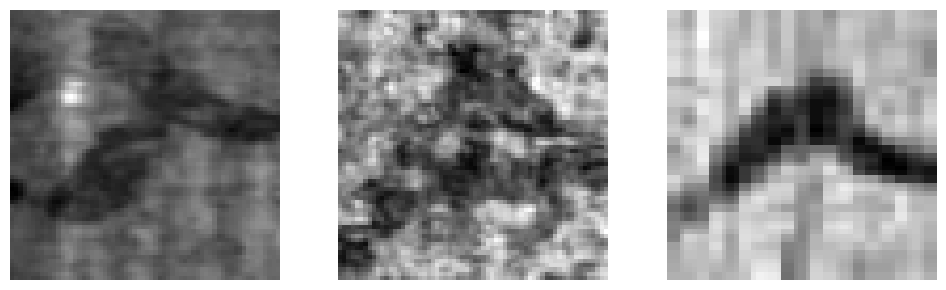

In [53]:
#@title Visualize Spectral Clustering Prototypes for Letters with 3 Clusters
from sklearn.cluster import SpectralClustering
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.spatial.distance import cdist

# Assuming embeddings and labels contain the CNN embeddings and labels before augmentation
# Assuming optimal_clusters and optimal_clusters_spectral contain the optimal k for KMeans and Spectral Clustering per letter
# Assuming train_loader_no_aug provides access to the original images
# Assuming train_indices_2d and image_data_2d are available

# Use embeddings and labels from the training set before augmentation
embeddings = train_embeddings_no_aug
labels = train_labels_no_aug_supco

# Identify letters where optimal k is 3 for (either KMeans or) Spectral Clustering
letters_with_3_clusters = set()
#for c, k in optimal_clusters.items():
#    if k == 3:
#        letters_with_3_clusters.add(label_encoder.inverse_transform([c])[0])

for c, k in optimal_clusters_spectral.items():
     if k == 3:
        letters_with_3_clusters.add(label_encoder.inverse_transform([c])[0])

letters_with_3_clusters = sorted(list(letters_with_3_clusters))

if not letters_with_3_clusters:
    print("No letters found with an optimal number of 3 clusters based on KMeans or Spectral Clustering.")

for letter in letters_with_3_clusters:
    print(f"\nVisualizing prototypes for Letter: {letter}")

    # Get the index for this letter
    letter_idx = label_encoder.transform([letter])[0]

    # Subset embeddings and labels for this letter from the TRAINING SET
    class_indices_in_train_set = np.where(labels == letter_idx)[0]
    class_embeddings = embeddings[class_indices_in_train_set]
    class_true_labels = labels[class_indices_in_train_set] # Should all be the same letter_idx

    if len(class_embeddings) < 3:
         print(f"Not enough samples for letter {letter} in the training set ({len(class_embeddings)}) to form 3 clusters.")
         continue

    # Perform Spectral Clustering with k=3 to get cluster assignments
    try:
        spectral = SpectralClustering(n_clusters=3,
                                      assign_labels='discretize', # or 'kmeans'
                                      random_state=42,
                                      affinity='nearest_neighbors',
                                      n_neighbors=min(10, len(class_embeddings) - 1)) # Number of neighbors

        clusters = spectral.fit_predict(class_embeddings)

        # Check if 3 distinct clusters were found
        if len(np.unique(clusters)) < 3:
             print(f"Spectral Clustering found less than 3 clusters for letter {letter}. Skipping prototype visualization.")
             continue

        plt.figure(figsize=(10, 3))
        #plt.suptitle(f"Prototypes for Letter: {letter} (Spectral Clustering with k=3)", fontsize=14)

        for cluster_id in range(3):
            # Find the medoid (sample closest to the centroid) for each cluster
            cluster_samples_indices_in_subset = np.where(clusters == cluster_id)[0]
            if len(cluster_samples_indices_in_subset) > 0:
                cluster_samples_embeddings = class_embeddings[cluster_samples_indices_in_subset]
                centroid = cluster_samples_embeddings.mean(axis=0)
                distances_to_centroid = cdist(cluster_samples_embeddings, centroid.reshape(1, -1)).squeeze()
                medoid_index_in_subset = cluster_samples_indices_in_subset[np.argmin(distances_to_centroid)]

                # The index within the training set corresponding to this medoid sample is:
                idx_in_train_set = class_indices_in_train_set[medoid_index_in_subset]

                # Get the original image from the loader using the index within the train subset
                try:
                    img, _ = train_loader_no_aug.dataset[idx_in_train_set]

                    if isinstance(img, torch.Tensor):
                        img = img.squeeze().cpu().numpy()

                    plt.subplot(1, 3, cluster_id + 1)
                    plt.imshow(img, cmap="gray")
                    #plt.title(f"Cluster {cluster_id}")
                    plt.axis("off")
                except IndexError:
                     print(f"Error retrieving image for letter {letter}, cluster {cluster_id} at training set index {idx_in_train_set}. Index might be out of bounds for the dataset.")
                     continue
            else:
                print(f"Warning: Cluster {cluster_id} for letter {letter} is empty. Skipping prototype visualization.")


        #plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error performing Spectral Clustering for letter {letter}: {e}")
        continue


Visualizing prototypes for Letter: Alpha (Optimal k = 3)


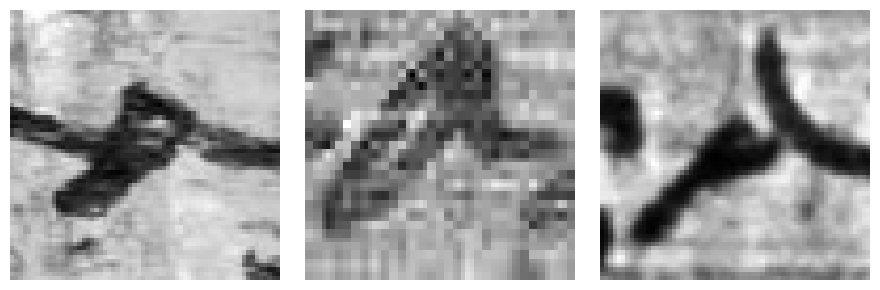


Visualizing prototypes for Letter: Beta (Optimal k = 2)


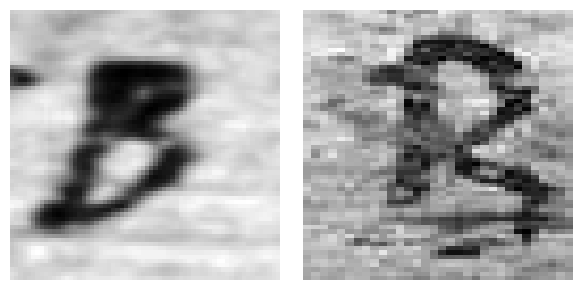


Visualizing prototypes for Letter: Chi (Optimal k = 2)


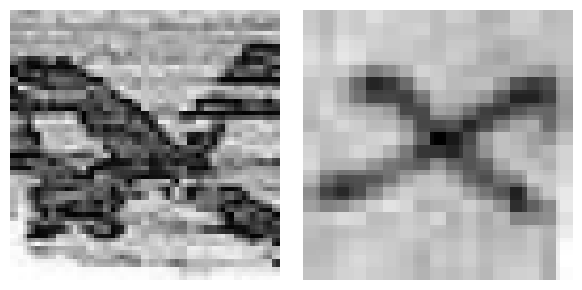


Visualizing prototypes for Letter: Delta (Optimal k = 2)


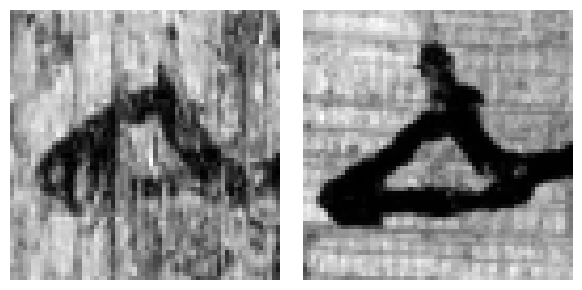


Visualizing prototypes for Letter: Epsilon (Optimal k = 2)


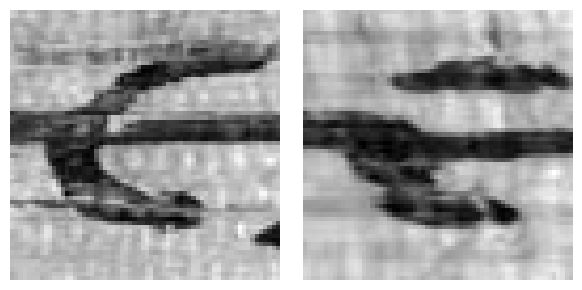


Visualizing prototypes for Letter: Eta (Optimal k = 2)


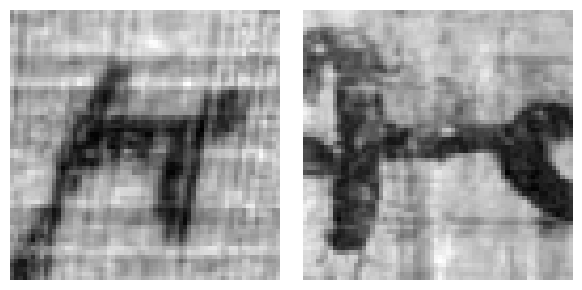


Visualizing prototypes for Letter: Gamma (Optimal k = 2)


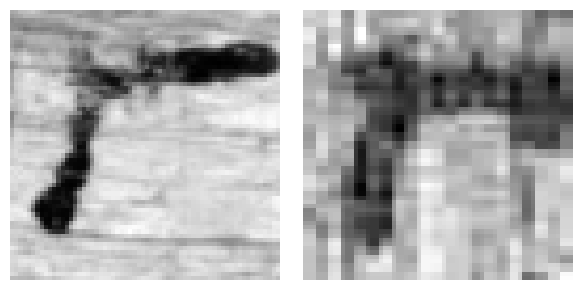


Visualizing prototypes for Letter: Iota (Optimal k = 2)


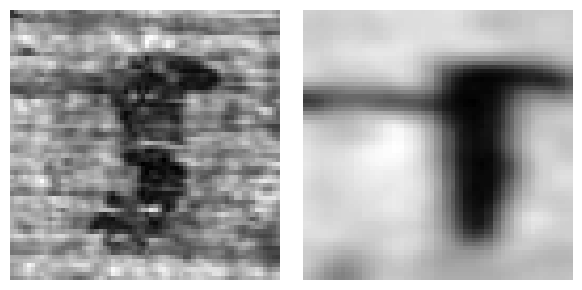


Visualizing prototypes for Letter: Kappa (Optimal k = 2)


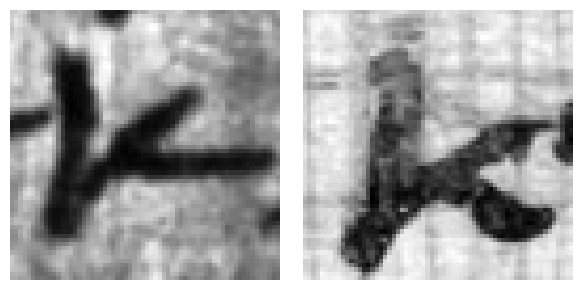


Visualizing prototypes for Letter: Lambda (Optimal k = 2)


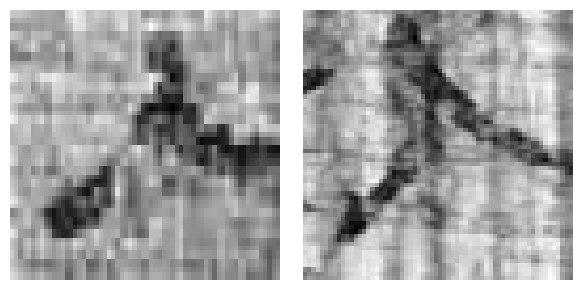


Visualizing prototypes for Letter: Mu (Optimal k = 2)


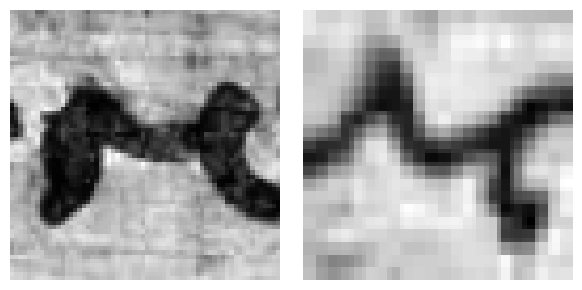


Visualizing prototypes for Letter: Nu (Optimal k = 2)


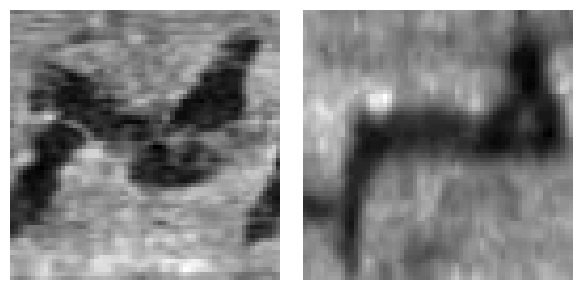


Visualizing prototypes for Letter: Omega (Optimal k = 2)


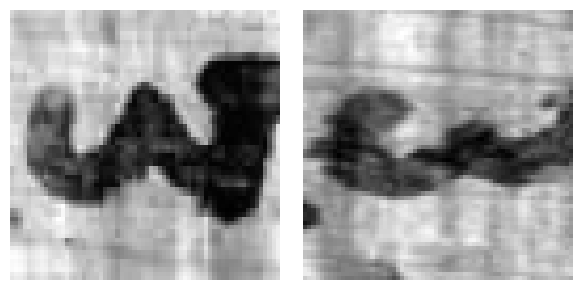


Visualizing prototypes for Letter: Omicron (Optimal k = 2)


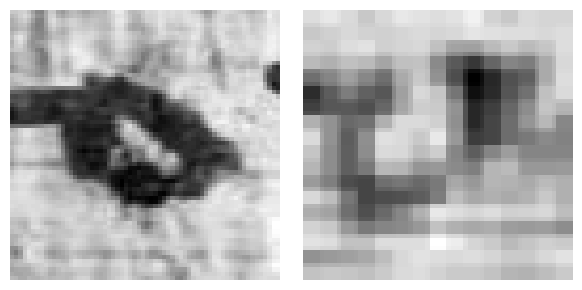


Visualizing prototypes for Letter: Phi (Optimal k = 2)


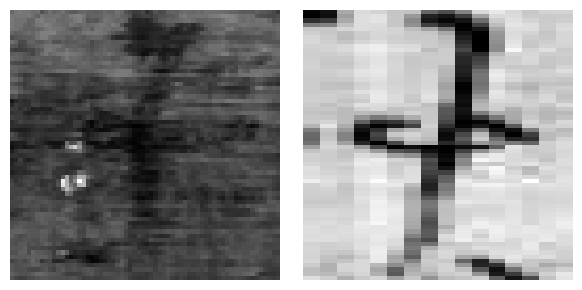


Visualizing prototypes for Letter: Pi (Optimal k = 2)


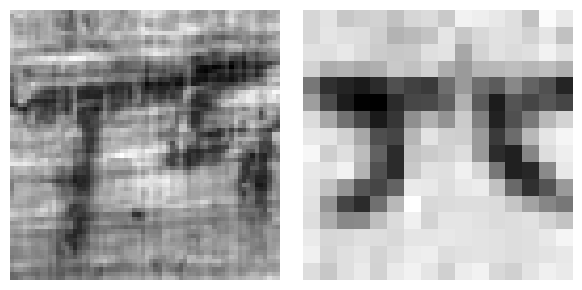


Visualizing prototypes for Letter: Psi (Optimal k = 2)


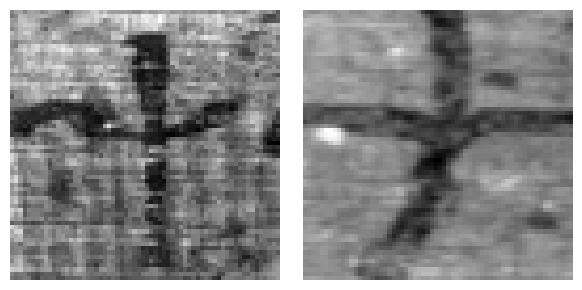


Visualizing prototypes for Letter: Rho (Optimal k = 2)


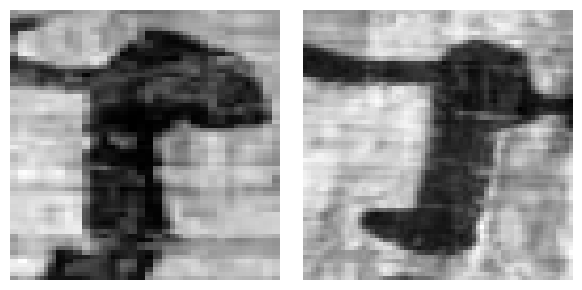


Visualizing prototypes for Letter: Sigma (Optimal k = 2)


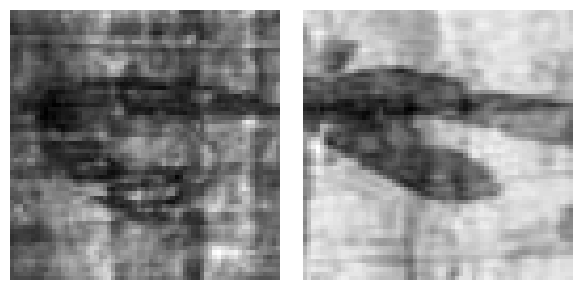


Visualizing prototypes for Letter: Tau (Optimal k = 2)


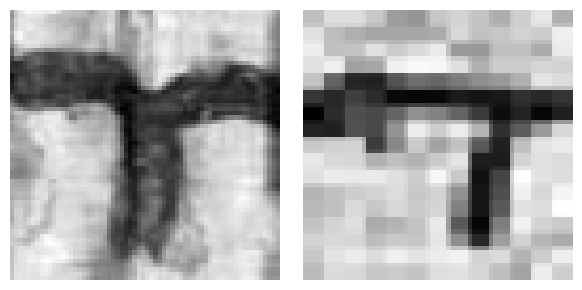


Visualizing prototypes for Letter: Theta (Optimal k = 2)


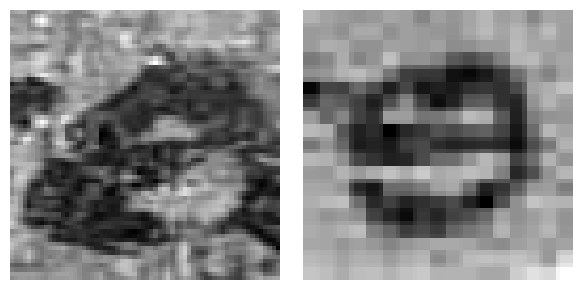


Visualizing prototypes for Letter: Upsilon (Optimal k = 2)


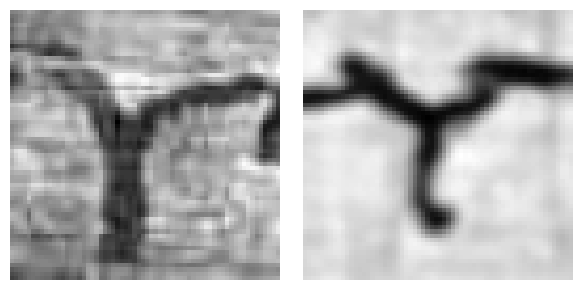


Visualizing prototypes for Letter: Xi (Optimal k = 2)


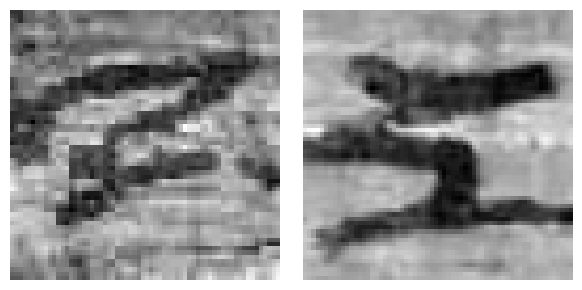


Visualizing prototypes for Letter: Zeta (Optimal k = 2)


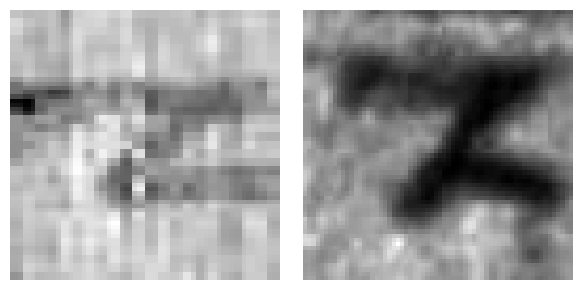

In [55]:
#@title Visualize Spectral Clustering Prototypes for Letters with Any Number of Clusters
from sklearn.cluster import SpectralClustering
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.spatial.distance import cdist

# Assuming embeddings and labels contain the CNN embeddings and labels before augmentation
# Assuming optimal_clusters_spectral contain the optimal k for Spectral Clustering per letter
# Assuming train_loader_no_aug provides access to the original images
# Assuming train_indices_2d and image_data_2d are available

# Use embeddings and labels from the training set before augmentation
embeddings = train_embeddings_no_aug_supcon
labels = train_labels_no_aug_supcon

# Iterate through all letters and their optimal number of clusters
for c, optimal_k in optimal_clusters_spectral.items():
    letter = label_encoder.inverse_transform([c])[0]
    print(f"\nVisualizing prototypes for Letter: {letter} (Optimal k = {optimal_k})")

    # Subset embeddings and labels for this letter from the TRAINING SET
    class_indices_in_train_set = np.where(labels == c)[0]
    class_embeddings = embeddings[class_indices_in_train_set]
    class_true_labels = labels[class_indices_in_train_set] # Should all be the same letter_idx

    if len(class_embeddings) < optimal_k:
         print(f"Not enough samples for letter {letter} in the training set ({len(class_embeddings)}) to form {optimal_k} clusters.")
         continue

    # Perform Spectral Clustering with the optimal k
    try:
        # Adjust n_neighbors for Spectral Clustering based on the number of samples
        n_neighbors_sc = min(10, len(class_embeddings) - 1)
        if n_neighbors_sc < 1:
             print(f"Not enough samples to determine nearest neighbors for letter {letter}. Skipping visualization.")
             continue

        spectral = SpectralClustering(n_clusters=optimal_k,
                                      assign_labels='discretize', # or 'kmeans'
                                      random_state=42,
                                      affinity='nearest_neighbors',
                                      n_neighbors=n_neighbors_sc)

        clusters = spectral.fit_predict(class_embeddings)

        # Check if the optimal_k distinct clusters were found
        if len(np.unique(clusters)) < optimal_k:
             print(f"Spectral Clustering found less than {optimal_k} distinct clusters for letter {letter}. Skipping prototype visualization.")
             continue

        plt.figure(figsize=(optimal_k * 3, 3)) # Adjust figure size based on number of clusters
        #plt.suptitle(f"Prototypes for Letter: {letter} (Spectral Clustering with k={optimal_k})", fontsize=14)

        for cluster_id in range(optimal_k):
            # Find the medoid (sample closest to the centroid) for each cluster
            cluster_samples_indices_in_subset = np.where(clusters == cluster_id)[0]
            if len(cluster_samples_indices_in_subset) > 0:
                cluster_samples_embeddings = class_embeddings[cluster_samples_indices_in_subset]
                centroid = cluster_samples_embeddings.mean(axis=0)
                distances_to_centroid = cdist(cluster_samples_embeddings, centroid.reshape(1, -1)).squeeze()
                medoid_index_in_subset = cluster_samples_indices_in_subset[np.argmin(distances_to_centroid)]

                # The index within the training set corresponding to this medoid sample is:
                idx_in_train_set = class_indices_in_train_set[medoid_index_in_subset]

                # Get the original image from the loader using the index within the train subset
                try:
                    img, _ = train_loader_no_aug.dataset[idx_in_train_set]

                    if isinstance(img, torch.Tensor):
                        img = img.squeeze().cpu().numpy()

                    plt.subplot(1, optimal_k, cluster_id + 1)
                    plt.imshow(img, cmap="gray")
                    #plt.title(f"Cluster {cluster_id}")
                    plt.axis("off")
                except IndexError:
                     print(f"Error retrieving image for letter {letter}, cluster {cluster_id} at training set index {idx_in_train_set}. Index might be out of bounds for the dataset.")
                     continue
            else:
                print(f"Warning: Cluster {cluster_id} for letter {letter} is empty. Skipping prototype visualization.")

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error performing Spectral Clustering for letter {letter} with k={optimal_k}: {e}")
        continue